<a href="https://colab.research.google.com/github/muhammadzohaib09001-dotcom/FACIAL_EMOTION_RECOGNATION_USING_CNN_TRANSFER_LEARNING/blob/main/FACIAL_EMOTION_RECOGNATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Libraries

In [1]:
import os
import math
import numpy as np
import pandas as pd
from PIL import Image
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Importing Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Importing Data from Drive

In [3]:
OUTER = "/content/drive/MyDrive/FACIAL_EMOTION_RECOGNATION/Dataset"          # outer folder (has the CSV)
INNER = os.path.join(OUTER, "dataset")            # inner folder (has image folders)
CSV_NAME = "data.csv"                           # your csv file name
PATH_COL = "path"                                 # column containing image path
LABEL_COL = "label"

In [4]:
csv_path = os.path.join(OUTER, CSV_NAME)
df = pd.read_csv(csv_path)

# Fix nested paths if needed (handles "dataset/..." at start)
df[PATH_COL] = df[PATH_COL].astype(str).str.replace(r"^dataset/", "", regex=True)

# Build absolute paths
df["full_path"] = df[PATH_COL].apply(lambda p: os.path.join(INNER, p))

# Missing files check ---
exists = df["full_path"].apply(os.path.exists)
print(" Files found:", int(exists.sum()))
print(" Missing files:", int((~exists).sum()))

# Keep only valid rows for the rest
df_ok = df[exists].copy()

 Files found: 15453
 Missing files: 0


# Class distribution

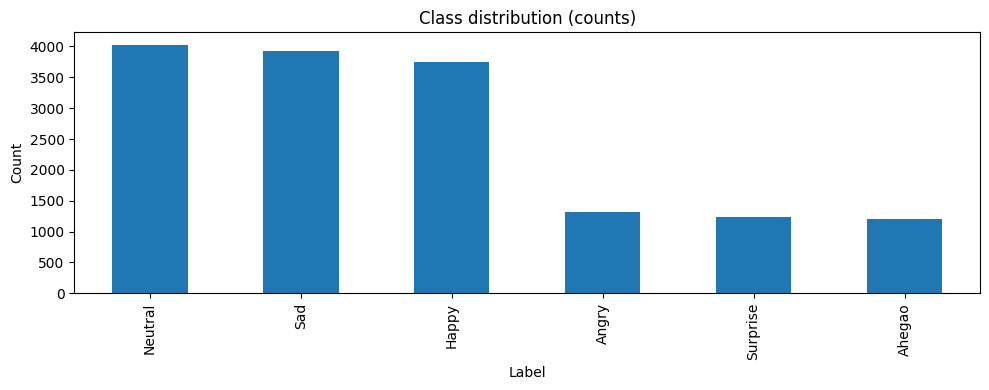

In [5]:
counts = df_ok[LABEL_COL].value_counts()
plt.figure(figsize=(10,4))
counts.plot(kind="bar")
plt.title("Class distribution (counts)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

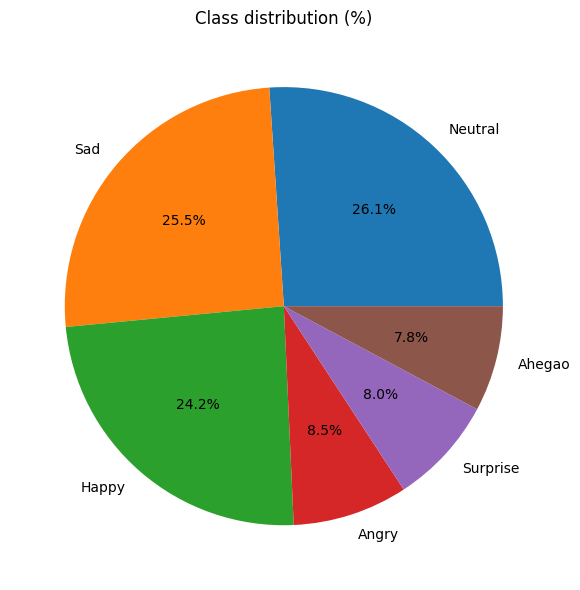

In [6]:
plt.figure(figsize=(6,6))
counts.plot(kind="pie", autopct="%.1f%%")
plt.ylabel("")
plt.title("Class distribution (%)")
plt.tight_layout()
plt.show()

# Show sample images

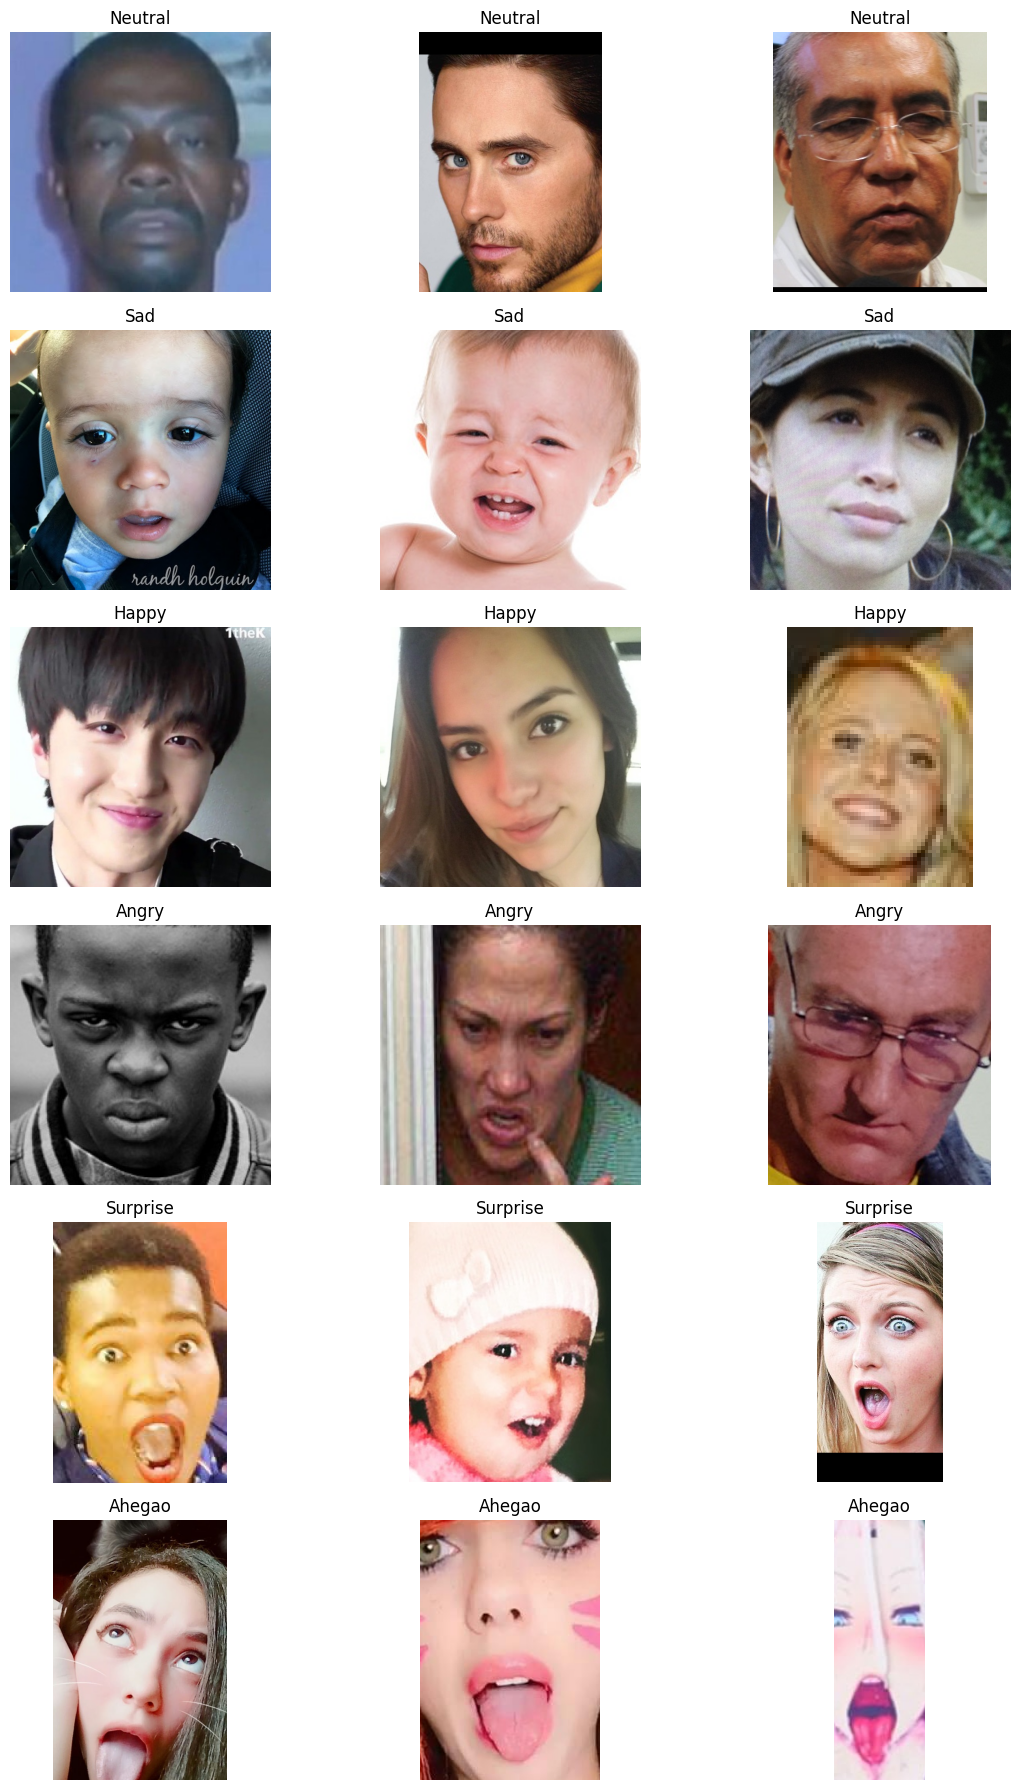

In [7]:
classes = counts.index.tolist()
n_per_class = 3
plt.figure(figsize=(12, 3 * len(classes)))

plot_idx = 1
for cls in classes:
    sample = df_ok[df_ok[LABEL_COL] == cls].sample(min(n_per_class, (df_ok[LABEL_COL] == cls).sum()), random_state=0)
    for _, row in sample.iterrows():
        img = Image.open(row["full_path"]).convert("RGB")
        plt.subplot(len(classes), n_per_class, plot_idx)
        plt.imshow(img)
        plt.title(str(cls))
        plt.axis("off")
        plot_idx += 1

plt.tight_layout()
plt.show()

# Image size + aspect ratio distributions

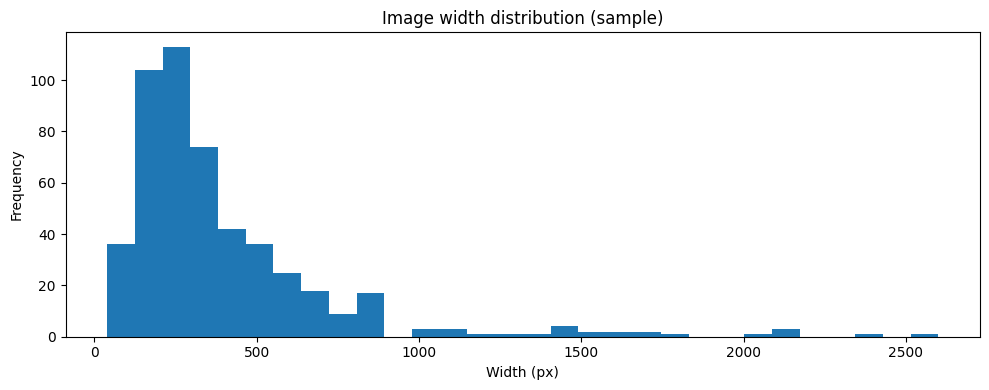

In [8]:
widths, heights, ratios = [], [], []
for p in df_ok["full_path"].sample(min(500, len(df_ok)), random_state=0):
    try:
        with Image.open(p) as im:
            w, h = im.size
        widths.append(w); heights.append(h); ratios.append(w / h if h else 0)
    except:
        pass

plt.figure(figsize=(10,4))
plt.hist(widths, bins=30)
plt.title("Image width distribution (sample)")
plt.xlabel("Width (px)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

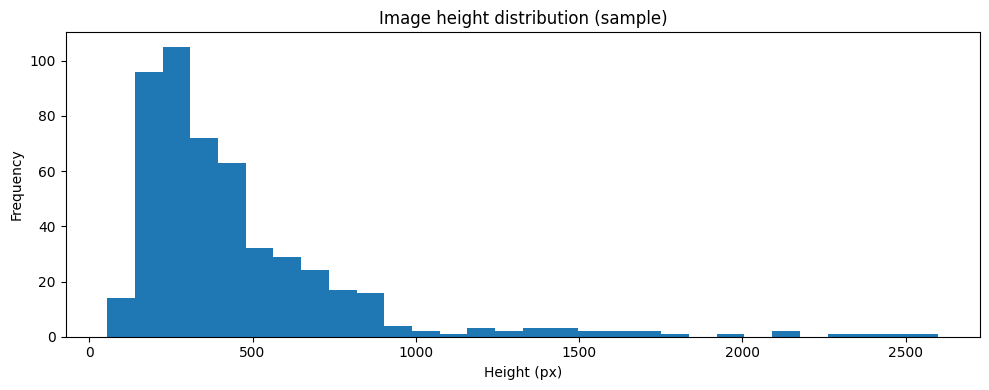

In [9]:
plt.figure(figsize=(10,4))
plt.hist(heights, bins=30)
plt.title("Image height distribution (sample)")
plt.xlabel("Height (px)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

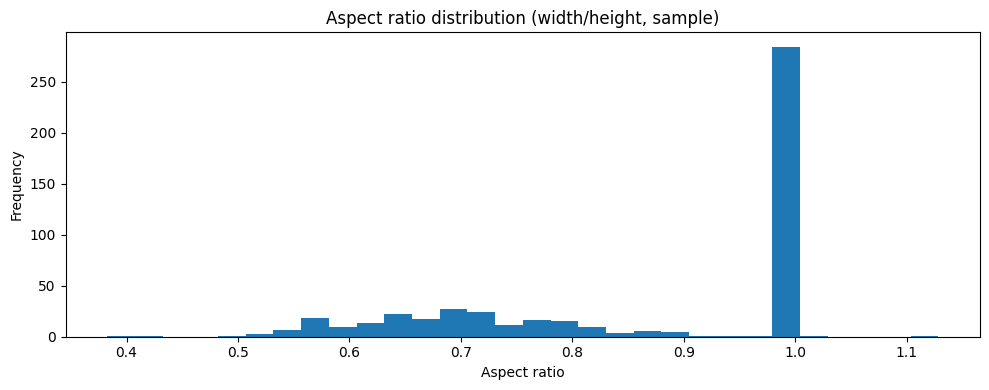

In [10]:
plt.figure(figsize=(10,4))
plt.hist(ratios, bins=30)
plt.title("Aspect ratio distribution (width/height, sample)")
plt.xlabel("Aspect ratio")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Image Processing

In [11]:
IMG_H, IMG_W = 64, 64      # Image Sizw
CHANNELS = 3                # 3 for RGB Images
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE
LABEL_COL = "label"         # label col is "label"

# Getting Paths and Labels

In [12]:
paths = df_ok["full_path"].astype(str).values
labels_str = df_ok[LABEL_COL].astype(str).values

class_names = sorted(df_ok[LABEL_COL].astype(str).unique().tolist())
num_classes = len(class_names)
print("Class names:", class_names)

label_to_id = {name: i for i, name in enumerate(class_names)}
labels = np.array([label_to_id[x] for x in labels_str], dtype=np.int32)

Class names: ['Ahegao', 'Angry', 'Happy', 'Neutral', 'Sad', 'Surprise']


# TRAIN / VAL / TEST SPLIT (STRATIFIED)

In [13]:
X_train, X_temp, y_train, y_temp = train_test_split(
    paths, labels, test_size=0.30, random_state=SEED, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)
print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))

Train: 10817 Val: 2318 Test: 2318


# CHECK CLASS DISTRIBUTION

In [14]:
u, c = np.unique(y_train, return_counts=True)
print("Train distribution:")
for cls_id, cnt in zip(u, c):
    print(f"  {class_names[int(cls_id)]}: {int(cnt)}")

Train distribution:
  Ahegao: 843
  Angry: 919
  Happy: 2618
  Neutral: 2819
  Sad: 2754
  Surprise: 864


# BUILD tf.data FOR VALIDATION / TEST (NO AUGMENTATION)

In [15]:
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.map(
    lambda p, y: (
        tf.image.resize(
            tf.image.convert_image_dtype(
                tf.image.decode_image(tf.io.read_file(p), channels=CHANNELS, expand_animations=False),
                tf.float32
            ),
            (IMG_H, IMG_W)
        ),
        y
    ),
    num_parallel_calls=AUTOTUNE
)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(
    lambda p, y: (
        tf.image.resize(
            tf.image.convert_image_dtype(
                tf.image.decode_image(tf.io.read_file(p), channels=CHANNELS, expand_animations=False),
                tf.float32
            ),
            (IMG_H, IMG_W)
        ),
        y
    ),
    num_parallel_calls=AUTOTUNE
)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# BALANCE THE TRAINING DATA (OVERSAMPLING)

In [16]:
counts = np.bincount(y_train, minlength=num_classes)
max_count = int(counts.max())
print("Class counts:", counts, "max:", max_count)

balanced_paths = []
balanced_labels = []

rng = np.random.default_rng(SEED)

for cls in range(num_classes):
    idx = np.where(y_train == cls)[0]
    cls_paths = X_train[idx]

    # sample with replacement up to max_count
    if len(cls_paths) == 0:
        continue
    chosen = rng.choice(cls_paths, size=max_count, replace=True)

    balanced_paths.append(chosen)
    balanced_labels.append(np.full(shape=(max_count,), fill_value=cls, dtype=np.int32))

balanced_paths = np.concatenate(balanced_paths)
balanced_labels = np.concatenate(balanced_labels)

# shuffle balanced set
perm = rng.permutation(len(balanced_paths))
balanced_paths = balanced_paths[perm]
balanced_labels = balanced_labels[perm]

print("Balanced train size:", len(balanced_paths))

Class counts: [ 843  919 2618 2819 2754  864] max: 2819
Balanced train size: 16914


# DATA AUGMENTATION LAYERS (APPLY ONLY TO TRAIN)

In [17]:
augmenter = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.10),
        tf.keras.layers.RandomZoom(0.10),
        tf.keras.layers.RandomTranslation(0.08, 0.08),
        tf.keras.layers.RandomContrast(0.15),
    ]
)

# BUILD TRAIN DATASET (DECODE -> RESIZE -> AUGMENT)

In [18]:
train_ds = tf.data.Dataset.from_tensor_slices((balanced_paths, balanced_labels))
train_ds = train_ds.shuffle(buffer_size=min(len(balanced_paths), 8000), seed=SEED, reshuffle_each_iteration=True)

train_ds = train_ds.map(
    lambda p, y: (
        tf.image.resize(
            tf.image.convert_image_dtype(
                tf.image.decode_image(tf.io.read_file(p), channels=CHANNELS, expand_animations=False),
                tf.float32
            ),
            (IMG_H, IMG_W)
        ),
        y
    ),
    num_parallel_calls=AUTOTUNE
)

# Apply augmentation

In [19]:
train_ds = train_ds.map(lambda x, y: (augmenter(x, training=True), y), num_parallel_calls=AUTOTUNE)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# (OPTIONAL) QUICK SANITY CHECK: one batch shape

In [20]:
for images, labs in train_ds.take(1):
    print("Train batch images:", images.shape, "labels:", labs.shape)

Train batch images: (32, 64, 64, 3) labels: (32,)


# CNN MODEL 1

In [21]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_H, IMG_W, CHANNELS)),

    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation="softmax"),
])


# Compiling Model

In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# Model Summary

In [23]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,022 (367.27 KB)

 Trainable params: 94,022 (367.27 KB)

 Non-trainable params: 0 (0.00 B)

# Training the model

In [24]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25
)

Epoch 1/25
529/529 ━━━━━━━━━━━━━━━━━━━━ 2931s 6s/step - accuracy: 0.2483 - loss: 1.7274 - val_accuracy: 0.3123 - val_loss: 1.5986
Epoch 2/25
529/529 ━━━━━━━━━━━━━━━━━━━━ 161s 305ms/step - accuracy: 0.3429 - loss: 1.5757 - val_accuracy: 0.3512 - val_loss: 1.5298
Epoch 3/25
529/529 ━━━━━━━━━━━━━━━━━━━━ 177s 334ms/step - accuracy: 0.3629 - loss: 1.5428 - val_accuracy: 0.3279 - val_loss: 1.6053
Epoch 4/25
529/529 ━━━━━━━━━━━━━━━━━━━━ 161s 305ms/step - accuracy: 0.3852 - loss: 1.4957 - val_accuracy: 0.3326 - val_loss: 1.5777
Epoch 5/25
529/529 ━━━━━━━━━━━━━━━━━━━━ 158s 298ms/step - accuracy: 0.4056 - loss: 1.4642 - val_accuracy: 0.3438 - val_loss: 1.5579
Epoch 6/25
529/529 ━━━━━━━━━━━━━━━━━━━━ 160s 303ms/step - accuracy: 0.4217 - loss: 1.4410 - val_accuracy: 0.3572 - val_loss: 1.5063
Epoch 7/25
529/529 ━━━━━━━━━━━━━━━━━━━━ 160s 302ms/step - accuracy: 0.4359 - loss: 1.4118 - val_accuracy: 0.3533 - val_loss: 1.6201
Epoch 8/25
529/529 ━━━━━━━━━━━━━━━━━━━━ 165s 313ms/step - accuracy: 0.4611 - l

# EVALUATE

In [25]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)

73/73 ━━━━━━━━━━━━━━━━━━━━ 768s 10s/step - accuracy: 0.5639 - loss: 1.0878
Test accuracy: 0.5780845284461975


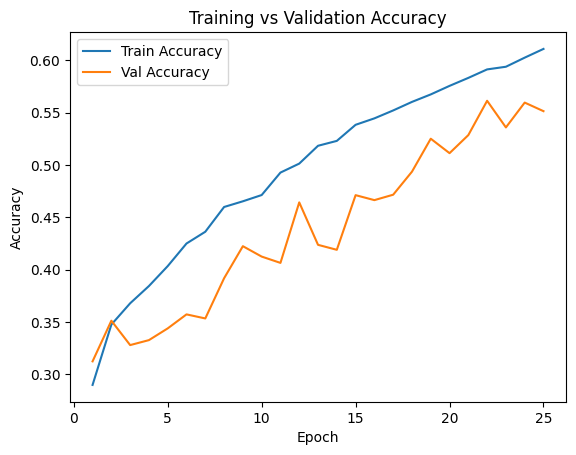

In [26]:
acc = history.history.get("accuracy", [])
val_acc = history.history.get("val_accuracy", [])
loss = history.history.get("loss", [])
val_loss = history.history.get("val_loss", [])

epochs = range(1, len(loss) + 1)

# Accuracy graph
plt.figure()
plt.plot(epochs, acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()